Normalized Roll Number :  [-0.91639704 -0.45539347 -1.08226076 -1.08957828 -1.05055152  1.12519019
  1.15689943  1.0544542   1.33008067 -0.07244342]
Training
Iteration 0 | MSE = 245.6000 | m = -0.0255 | c = 0.3120
Iteration 100 | MSE = 4.9287 | m = -1.1074 | c = 13.5725
Iteration 200 | MSE = 0.6957 | m = -1.2509 | c = 15.3311
Iteration 300 | MSE = 0.6213 | m = -1.2699 | c = 15.5643
Iteration 400 | MSE = 0.6200 | m = -1.2724 | c = 15.5953
Iteration 500 | MSE = 0.6200 | m = -1.2728 | c = 15.5994
Iteration 600 | MSE = 0.6200 | m = -1.2728 | c = 15.5999
Iteration 700 | MSE = 0.6200 | m = -1.2728 | c = 15.6000
Iteration 800 | MSE = 0.6200 | m = -1.2728 | c = 15.6000
Iteration 900 | MSE = 0.6200 | m = -1.2728 | c = 15.6000

Final Linear Regression Equation:
y = -1.2728x + 15.6000


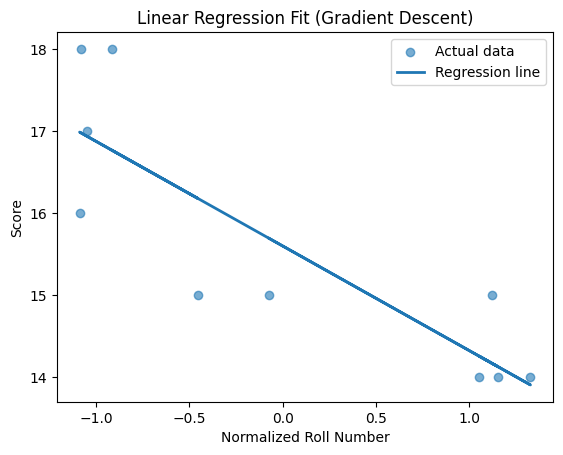

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

x = np.array([3504, 3693, 3436, 3433, 3449,
              4341, 4354, 4312, 4425, 3850], dtype=float)

y = np.array([18, 15, 18, 16, 17,
              15, 14, 14, 14, 15], dtype=float)
n = len(x)

#Normalize
x = (x - x.mean()) / x.std()
print("Normalized Roll Number : ",x[:10])
#Initialize Hyperparams
m = 0.0
c = 0.0
lr = 0.01
iterations = 1000
print("Training")
for i in range(iterations):
    y_pred = m * x + c #y_pred is a list
    #E
    error = y - y_pred #error is a list
    #MSE
    mse = (1/n) * np.sum(error ** 2) #np.sum adds all elements of the list
    dm = (-2/n) * np.sum(x * error)
    dc = (-2/n) * np.sum(error)
    m = m - lr * dm
    c = c - lr * dc
    if i % 100 == 0:
        print(f"Iteration {i} | MSE = {mse:.4f} | m = {m:.4f} | c = {c:.4f}")


print("\nFinal Linear Regression Equation:")
print(f"y = {m:.4f}x + {c:.4f}")
# Generate predictions using the trained model
y_pred = m * x + c

plt.figure()
plt.scatter(x, y, label="Actual data", alpha=0.6)
plt.plot(x, y_pred, label="Regression line", linewidth=2)
plt.xlabel("Normalized Roll Number")
plt.ylabel("Score")
plt.title("Linear Regression Fit (Gradient Descent)")
plt.legend()
plt.show()


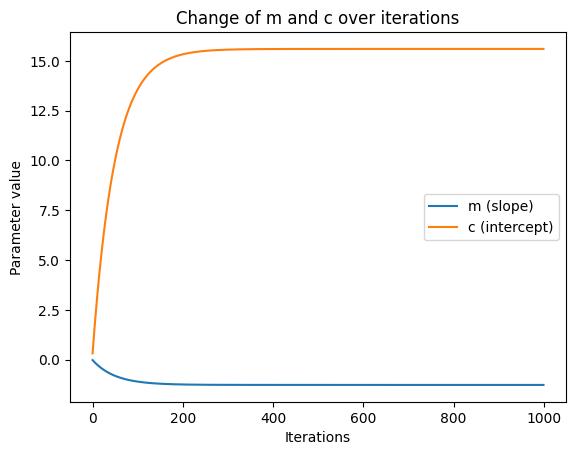

In [29]:
import matplotlib.pyplot as plt

# Lists to store parameter history
m_history = []
c_history = []

# Re-initialize parameters
mi = 0.0
ci = 0.0

# Training with tracking
for i in range(iterations):
    y_pred = mi * x + ci
    error = y - y_pred
    dm = (-2/n) * np.sum(x * error)
    dc = (-2/n) * np.sum(error)
    mi = mi - lr * dm
    ci = ci - lr * dc
    # Store values
    m_history.append(mi)
    c_history.append(ci)

# -----------------------------
# Plot m and c over iterations
# -----------------------------
plt.figure()
plt.plot(m_history, label="m (slope)")
plt.plot(c_history, label="c (intercept)")
plt.xlabel("Iterations")
plt.ylabel("Parameter value")
plt.title("Change of m and c over iterations")
plt.legend()
plt.show()
